# Plot global carbon pool evolution

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Set parameters

In [2]:
#stat = 'integral'#'integral'#'mean'
#freq_input = 'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['tas','fgco2','nbp','co2mass','fco2antt','dissic','cLand'] # ,'cLand','dissic'.  # 'tas','tos',
models = ['IPSL-CM6-ESMCO2']#,'GFDL-ESM2M','NorESM2-LM','UKESM1-2','EC-Earth3-ESM-1']#['GISSE2.1-G-CC2'].   #]#, ]#, # 
runs = pruns.get_run_list('tipmip_tier1')#[1:]
ref_year = 1
root_dir = f'./../01_postprocessed_data/global_time_series'


model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()

def get_freq_input(model):
    if model == 'GISSE2.1-G-CC2':
        freq_input = 'yearly'
    else:
        freq_input = 'monthly'
    return freq_input

## Convert time series

In [3]:
def convert_units(varia,stat,da):
    if varia == 'fgco2' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'nbp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'intpp' and stat == 'integral' and da.units in ['mol m-2 s-1 x m2','mol/m2/s x m2']:
        converter = 12 * 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'npp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kg/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'cLand' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cSoil' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cVeg' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'dissic' and stat == 'integral' and vert_stat == 'integral' and da.units in ['mol m-3 x m x m2']:
        converter = 12.0107 /1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'co2mass' and stat is None and vert_stat is None and da.units in ['kg']:
        converter = 12.0107 / 44.011 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'fco2antt' and stat == 'integral' and vert_stat is None and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'nbp' and stat == 'integral' and vert_stat is None and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'fgco2' and stat == 'integral' and vert_stat is None and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    else:
        da_conv = da
    return da_conv

def get_stat(varia,default=True):
    if default == True:
        if varia in ['tas','tos']:
            stat = 'mean'
        elif varia in ['fgco2','intpp','nbp','npp','cLand','cSoil','cVeg','cCwd','cLitter','dissic','fco2antt']:
            stat = 'integral'
        elif varia in ['co2mass']:
            stat = None
    else:
        stat = 'mean'
    return stat

def get_vert_stat(varia,default=True):
    if default == True:
        if varia in ['dissic']:
            vert_stat = 'integral'
        else:
            vert_stat = None
    else:
        vert_stat = None
    return vert_stat
    
def get_infix(varia,default=True):
    infix_base = 'vertical_'
    if default == True:
        if varia in ['dissic']:
            infix = infix_base+'integral_'
        else:
            infix = ''
    else:
        infix = ''
    return infix    

def get_suffix(varia,default=True):
    if default == True:
        if varia in ['fco2antt','fgco2','nbp']:
            suffix = '_cumulated'
        else:
            suffix = ''
    else:
        suffix = ''
    return suffix    

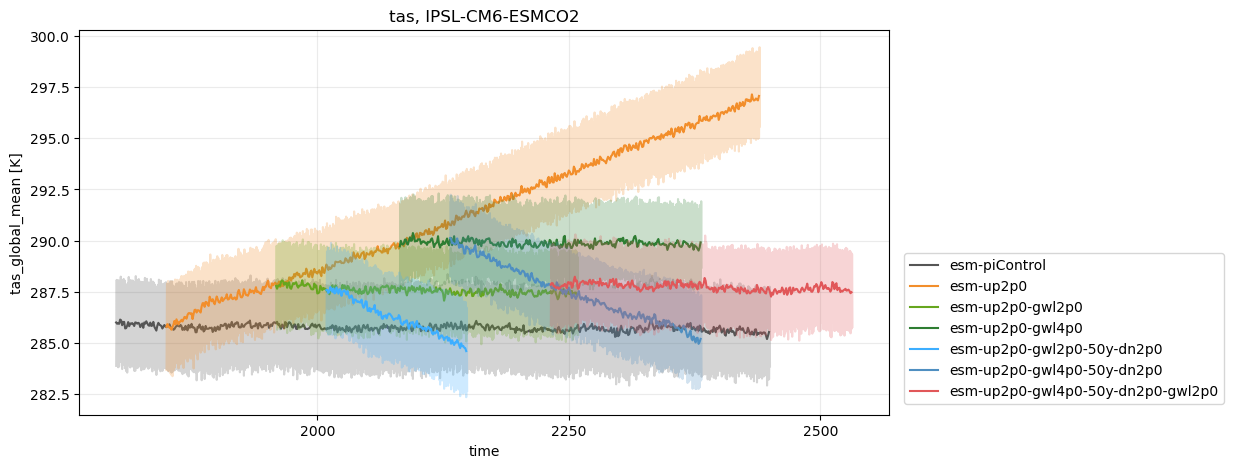

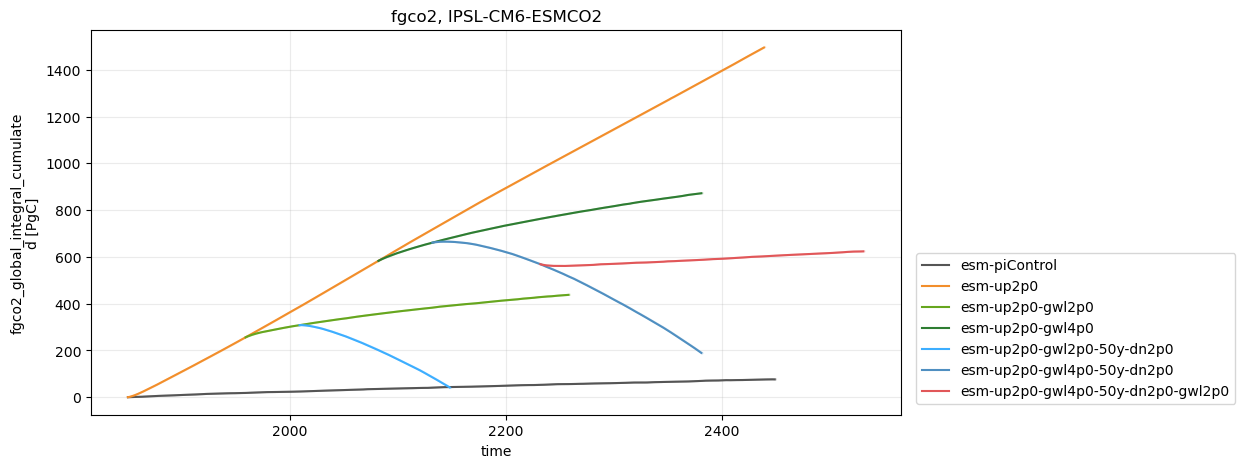

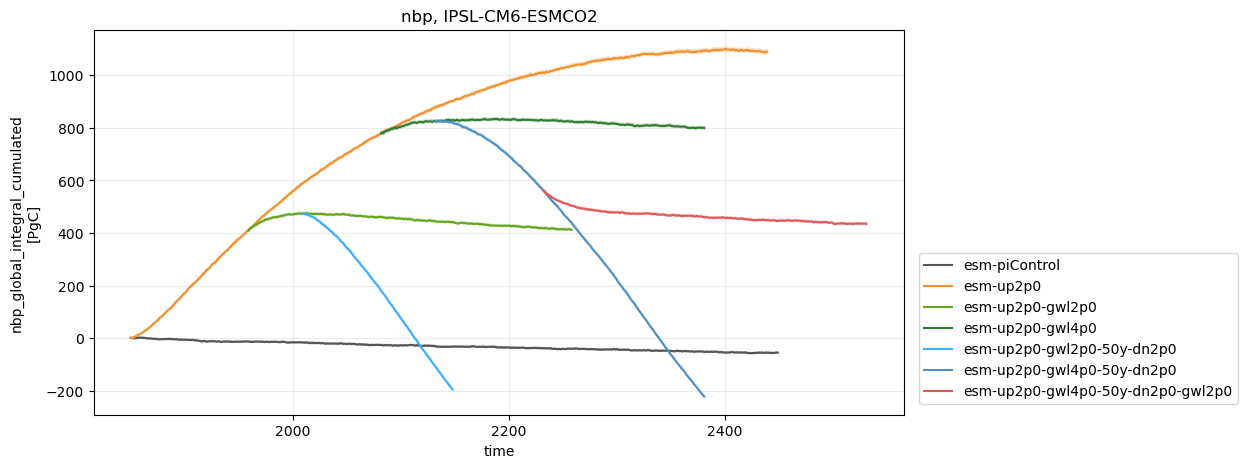

Nothing to plot for co2mass, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global None.
Nothing to plot for co2mass, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global None.


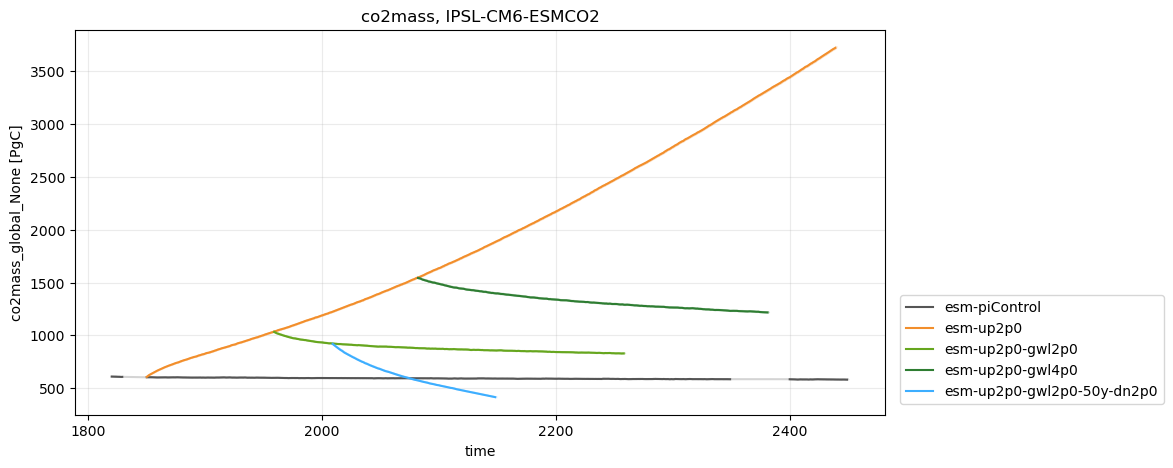

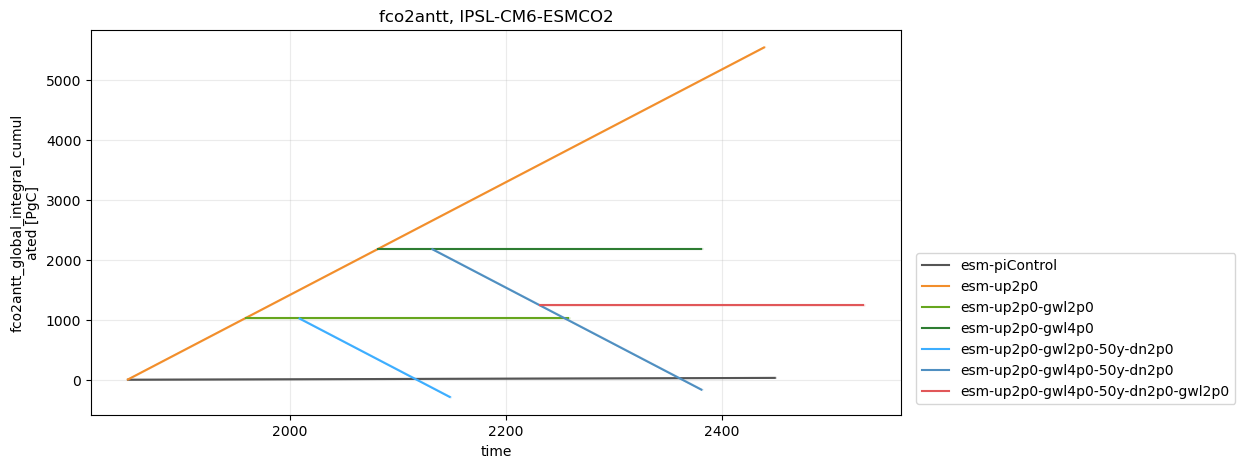

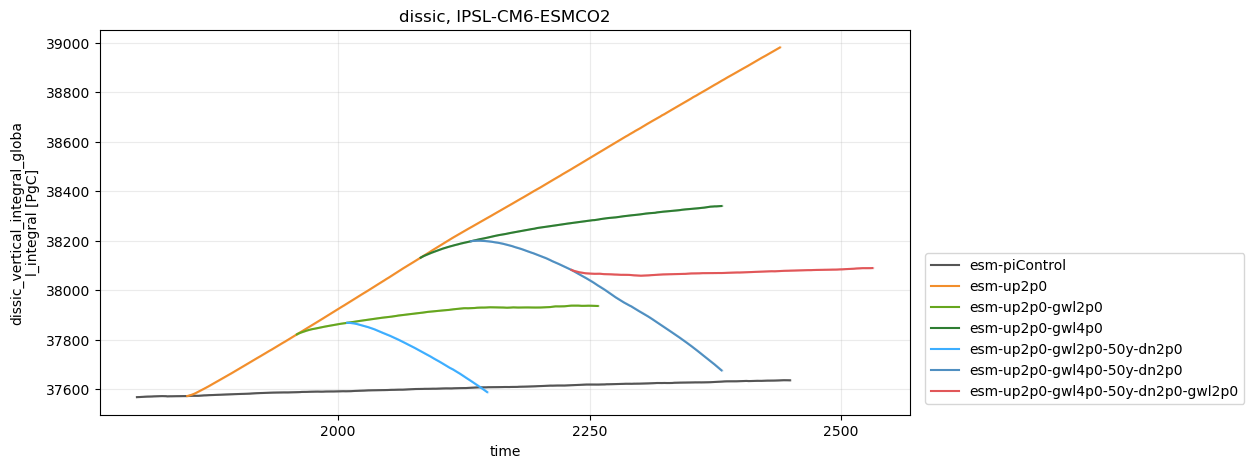

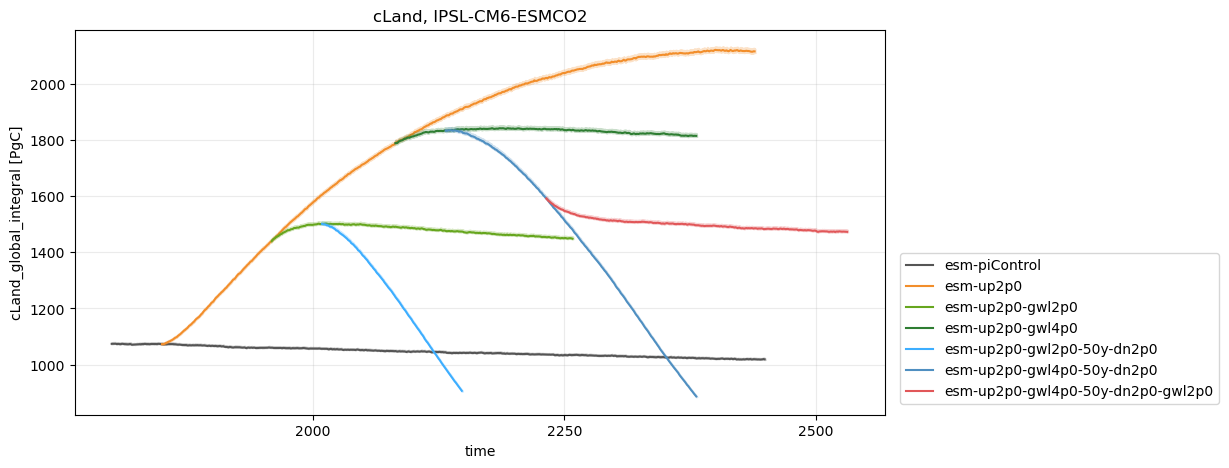

In [4]:
for varia in varias:
    for model in models:
        freq_input = get_freq_input(model)
        stat = get_stat(varia)
        vert_stat = get_vert_stat(varia,default=True)
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()
        infix = get_infix(varia,default=True)
        suffix = get_suffix(varia,default=True)
        #print(suffix)
        #color = model_dict[model].color_id
        global_stats = dict()
        fig, ax = plt.subplots(figsize=(12,5))
        for run in runs:
            try:
                color = run_dict[run].color_id
                load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}{suffix}'
                load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}{suffix}.nc'
                global_stat = xr.open_dataset(load_string,use_cftime=True)
                #print(global_stat)
                global_stat = global_stat[f"{varia}_{infix}global_{stat}{suffix}"]
                
                # convert
                global_stat = convert_units(varia,stat,global_stat)
    
                # put into dictionary
                global_stats[run] = global_stat
                #for key in global_stats.keys():
                #print(f'... plotting {run} ...')
                global_stats[run].plot(alpha=0.25,color=color)
                global_stats[run].resample(time="1YS").mean().plot(alpha=1,color=color,label=run)
            except:
                print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
        ax.set_title(f'{varia}, {model}')
        ax.grid(alpha=0.25)
        plt.subplots_adjust(right=0.8)
        plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
        plt.show()

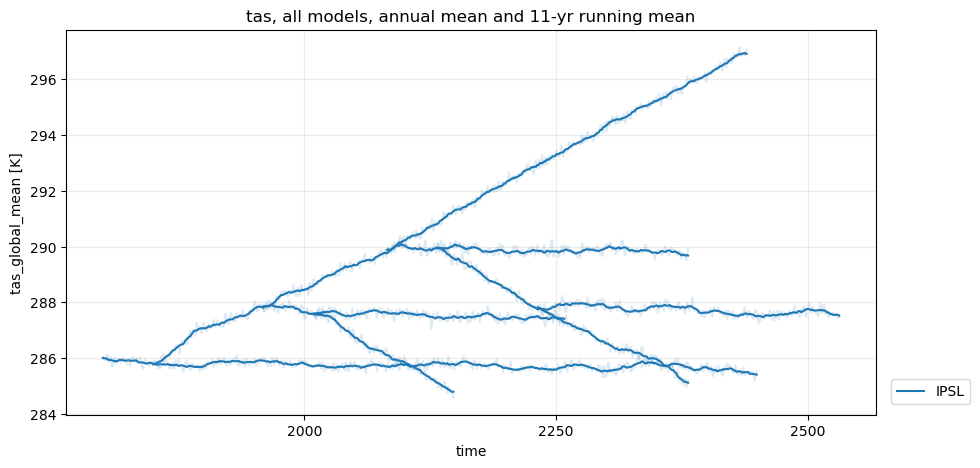

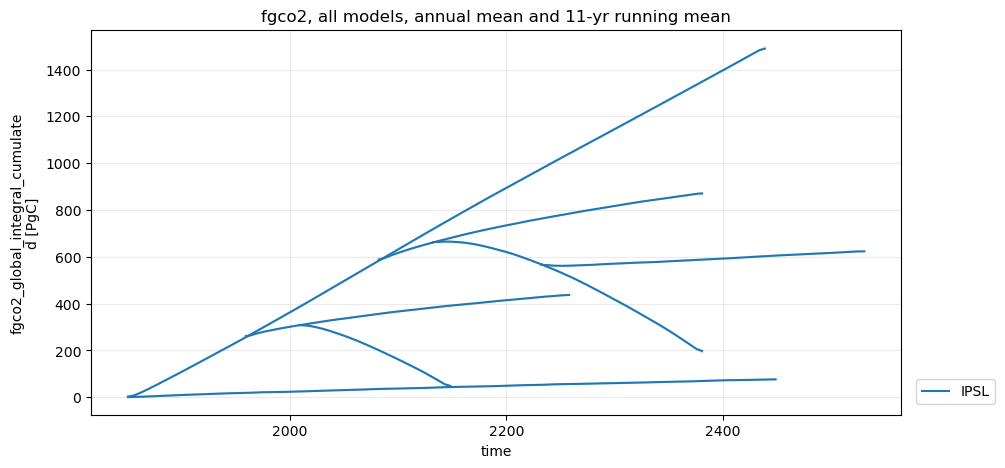

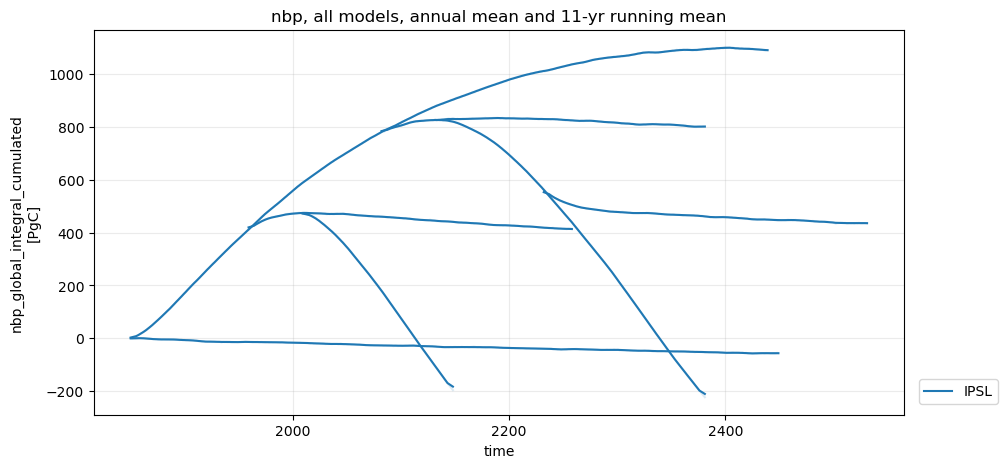

Nothing to plot for co2mass, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global None.
Nothing to plot for co2mass, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global None.


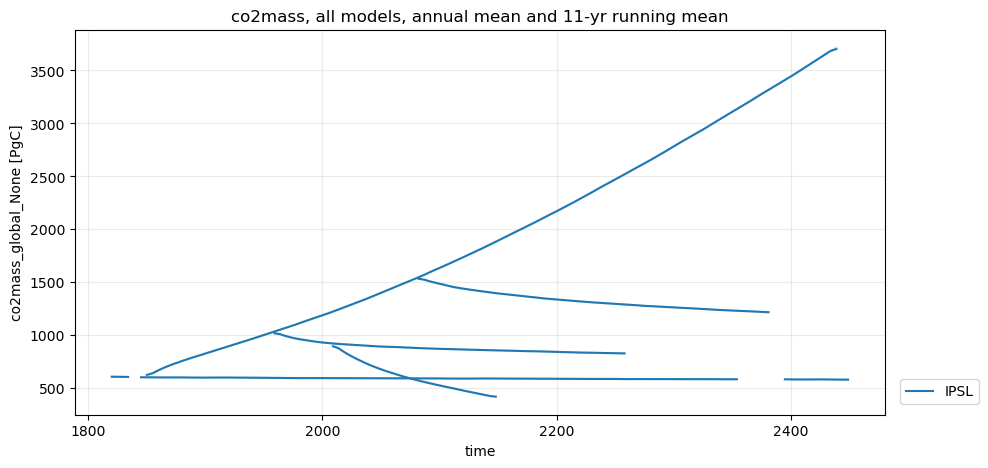

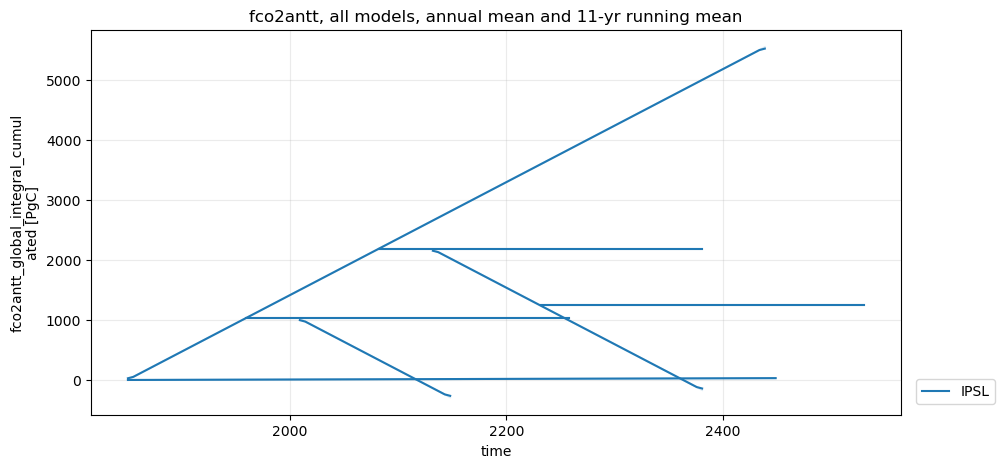

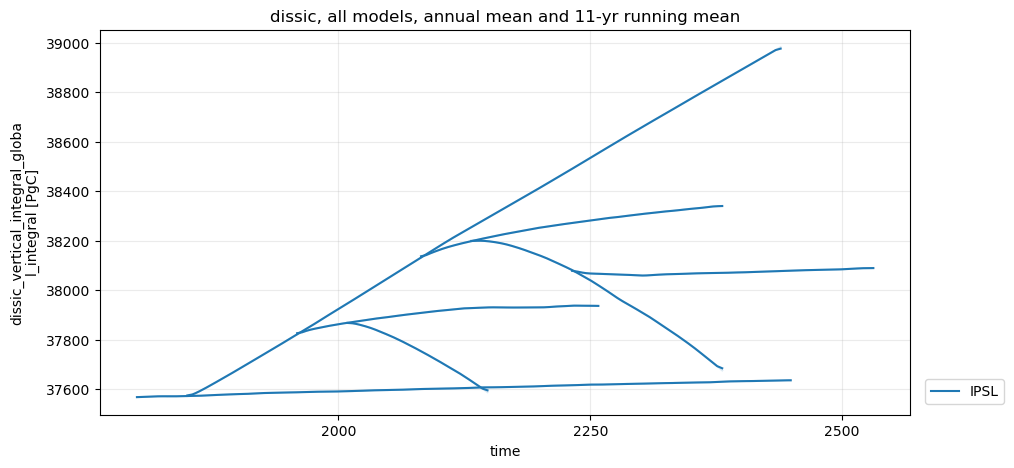

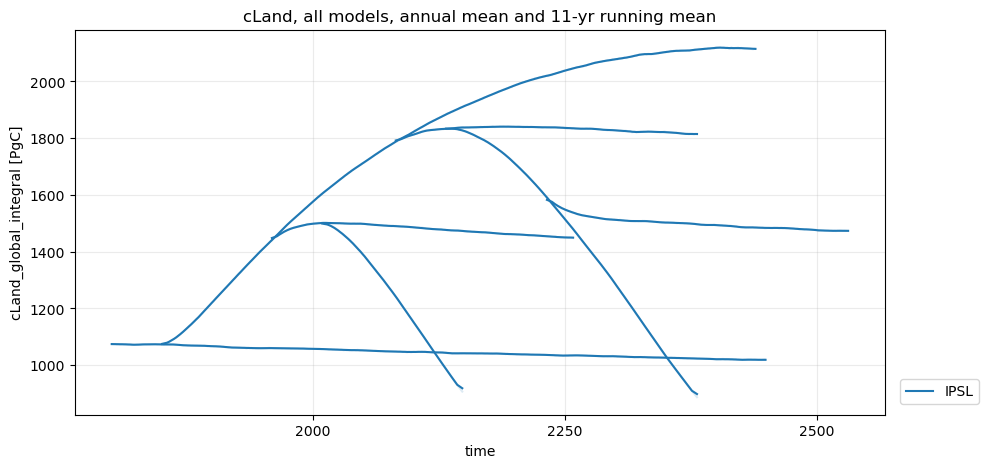

In [5]:
running_mean_years = 11

for varia in varias:
    fig, ax = plt.subplots(figsize=(12,5))
    for model in models:
        freq_input = get_freq_input(model)
        stat = get_stat(varia)
        vert_stat = get_vert_stat(varia,default=True)
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()
        infix = get_infix(varia,default=True)
        suffix = get_suffix(varia,default=True)
        #color = model_dict[model].color_id
        global_stats = dict()
        for run in runs:
            try:
                color = model_dict[model].color_id#run_dict[run].color_id
                load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}{suffix}'
                load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}{suffix}.nc'
                global_stat = xr.open_dataset(load_string,use_cftime=True)
                global_stat = global_stat[f"{varia}_{infix}global_{stat}{suffix}"]
    
                
                # convert
                global_stat = convert_units(varia,stat,global_stat)
    
                # put into dictionary
                global_stats[run] = global_stat
    
                annual_means = global_stat.resample(time="1YS").mean()
                annual_means.plot(alpha=.15,color=color)#,label=run)
    
                if run == 'esm-up2p0':
                    label=model_dict[model].plotting_name#model
                else:
                    label=''
                annual_means.rolling(time=running_mean_years,center=True,min_periods=1).mean().plot(alpha=1,color=color,label=label)#,label=run)
            except:
                print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
                
    ax.set_title(f'{varia}, all models, annual mean and {running_mean_years}-yr running mean')
    ax.grid(alpha=0.25)
    plt.subplots_adjust(right=0.8)
    plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
    plt.show()

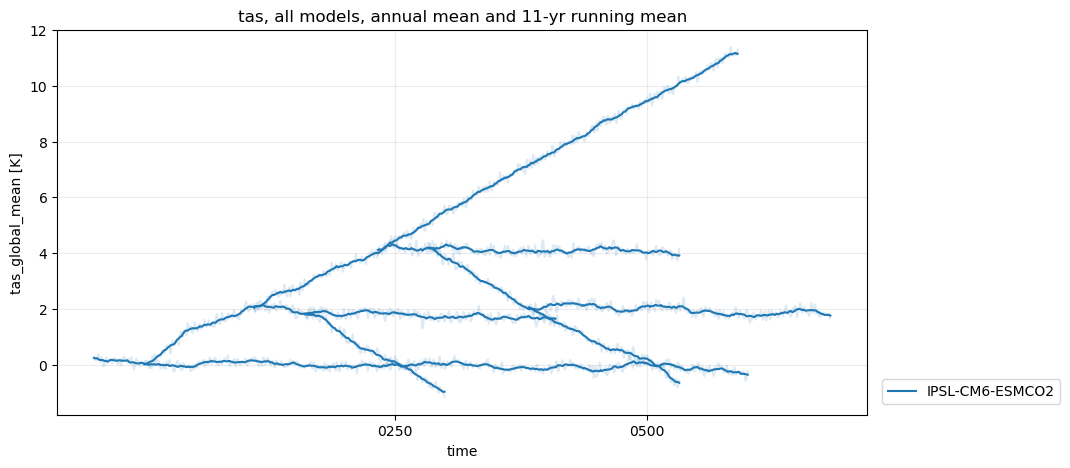

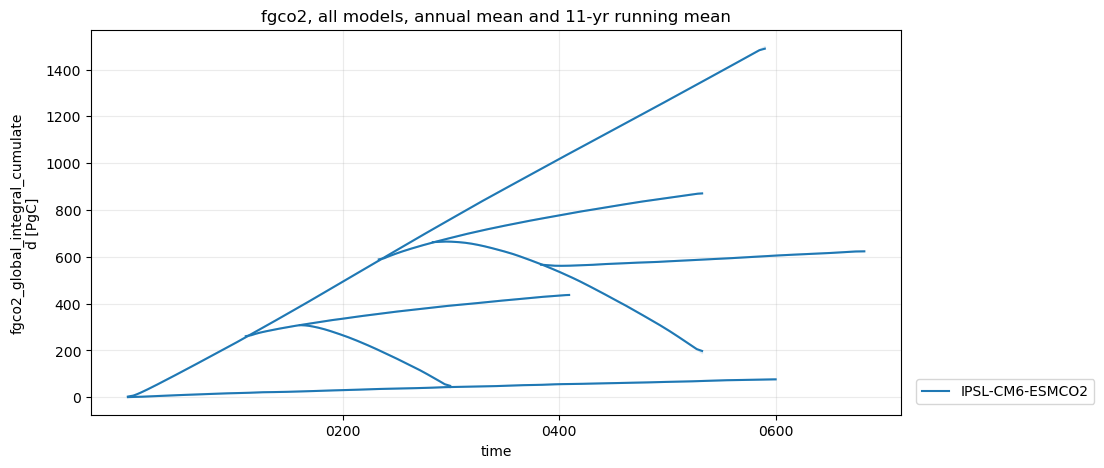

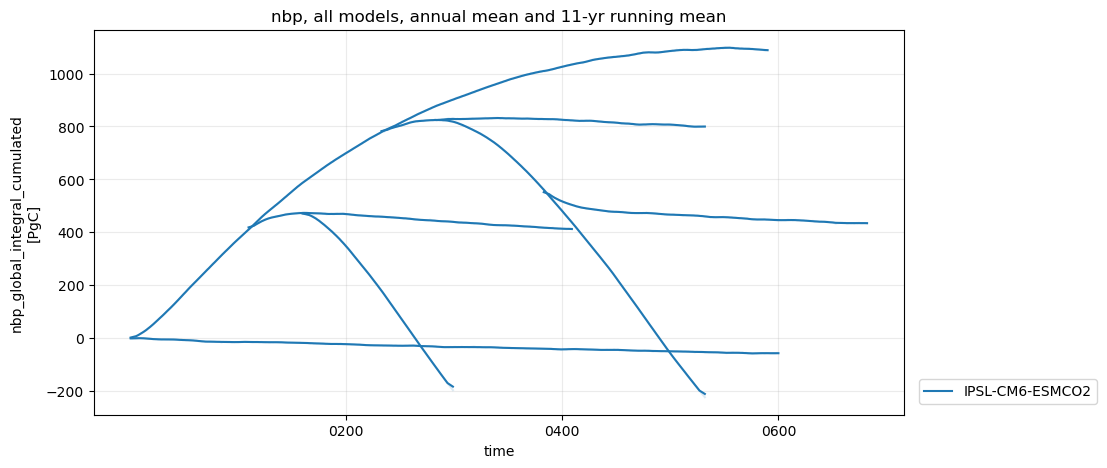

Nothing to plot for co2mass, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global None.
Nothing to plot for co2mass, IPSL-CM6-ESMCO2, r1i2p3f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global None.


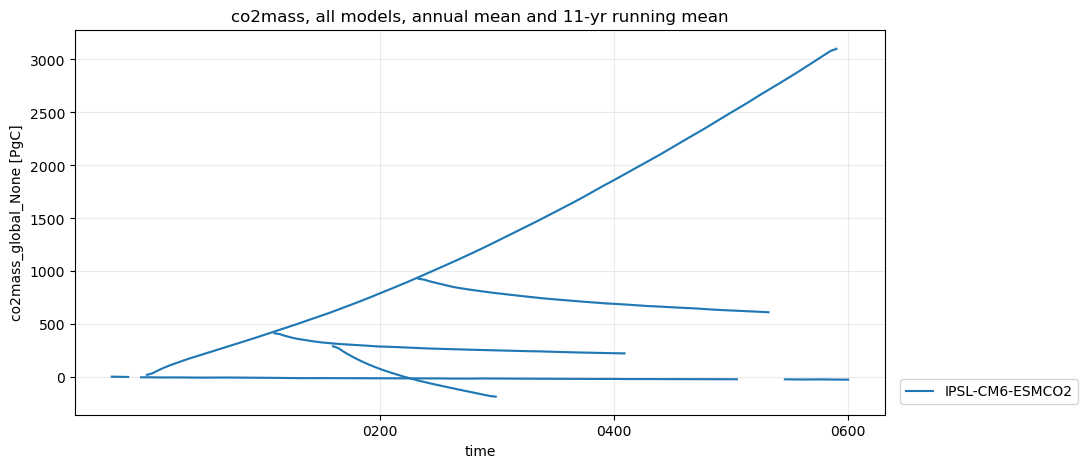

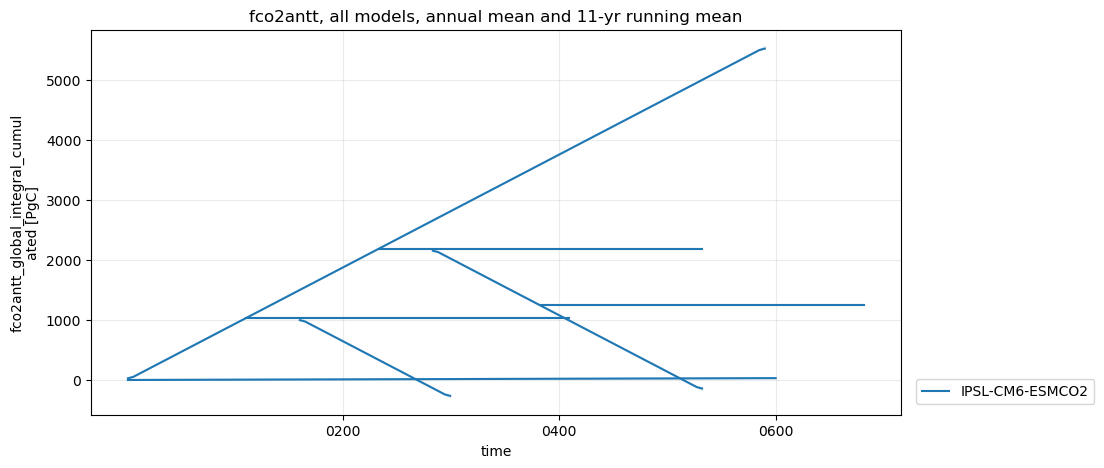

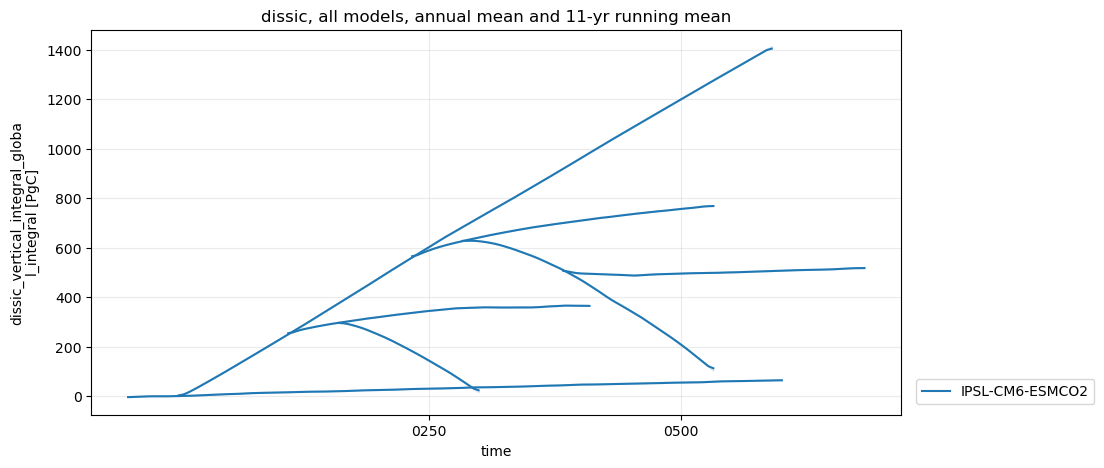

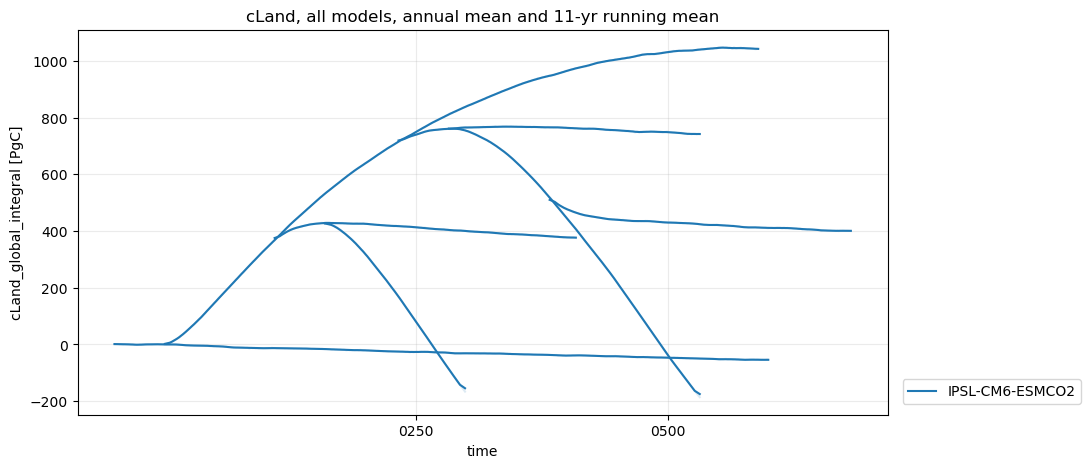

In [6]:
def get_reference_value(varia,model):
    freq_input = get_freq_input(model)
    stat = get_stat(varia)
    vert_stat = get_vert_stat(varia,default=True)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    infix = get_infix(varia,default=True)
    suffix = get_suffix(varia,default=True)
    run = 'esm-piControl'
    load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}{suffix}'
    load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}{suffix}.nc'
    global_stat = xr.open_dataset(load_string,use_cftime=True)
    global_stat = global_stat[f"{varia}_{infix}global_{stat}{suffix}"]
    #ref_year = 1
    global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
    annual_means = global_stat.resample(time="1YS").mean()
    #print(annual_means)
    reference_value = annual_means.sel(time=f'{ref_year:04d}-01-01').values
    
    return reference_value

running_mean_years = 11

all_global_stats = dict()
for varia in varias:
    all_global_stats[varia] = dict()
    fig, ax = plt.subplots(figsize=(12,5))
    for model in models:
        freq_input = get_freq_input(model)
        stat = get_stat(varia)
        vert_stat = get_vert_stat(varia,default=True)
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()
        infix = get_infix(varia,default=True)
        suffix = get_suffix(varia,default=True)
        #print(varia,model)
        #print(varia,model,reference_value)
        #color = model_dict[model].color_id
        global_stats = dict()
        for run in runs:
            try:
                reference_value = get_reference_value(varia,model)
                color = model_dict[model].color_id#run_dict[run].color_id
                load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}{suffix}'
                load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}{suffix}.nc'
                global_stat = xr.open_dataset(load_string,use_cftime=True)
                global_stat = global_stat[f"{varia}_{infix}global_{stat}{suffix}"]
                global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
    
                annual_means = global_stat.resample(time="1YS").mean() - reference_value
                annual_means.attrs['units'] = global_stat.units
                
                # convert
                annual_means = convert_units(varia,stat,annual_means)
    
                # put into dictionary
                global_stats[run] = annual_means
    
                if run == 'esm-up2p0':
                    label=model
                else:
                    label=''
                annual_means.plot(alpha=.15,color=color)#,label=run)
                annual_means.rolling(time=running_mean_years,center=True,min_periods=1).mean().plot(alpha=1,color=color,label=label)#,label=run)
            except:
                print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
        all_global_stats[varia][model] = global_stats    
    ax.set_title(f'{varia}, all models, annual mean and {running_mean_years}-yr running mean')
    ax.grid(alpha=0.25)
    plt.subplots_adjust(right=0.8)
    plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
    plt.show()

# Make the carbon pool plots

In [40]:
# ocean var
ocean_var = 'dissic' #'fgco2' # 'dissic'
land_var = 'cLand' #'nbp' # 'cLand'


Nothing to plot for IPSL-CM6-ESMCO2, esm-up2p0-gwl4p0-50y-dn2p0: 'esm-up2p0-gwl4p0-50y-dn2p0'
Nothing to plot for IPSL-CM6-ESMCO2, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0: 'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0'


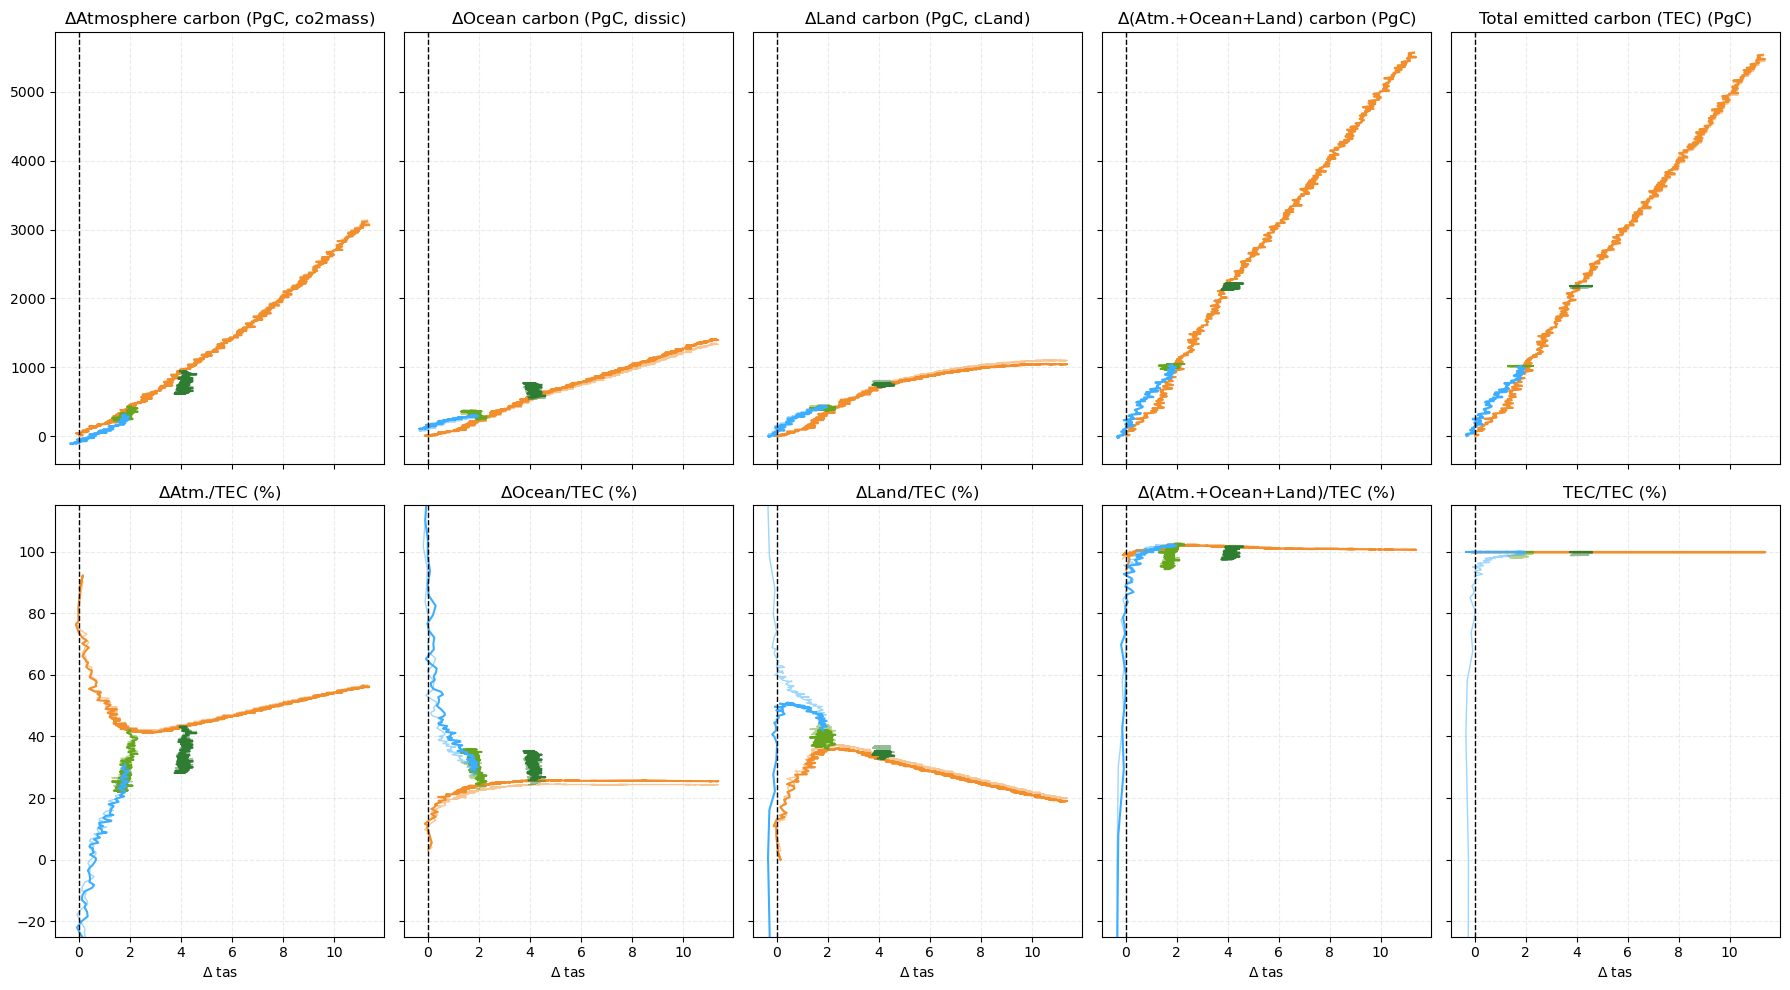

In [41]:
correct_for_piC = 'both' #['no', 'both']

for model in models:
    fig, ax = plt.subplots(2, 5, figsize=(18, 10), sharex=True,sharey='row')

    # --- reference (piControl) ---
    try:
        ref_cAtm = all_global_stats['co2mass'][model]['esm-piControl']
        ref_cOcean = all_global_stats[ocean_var][model]['esm-piControl']
        ref_cLand = all_global_stats[land_var][model]['esm-piControl']
        ref_cEm = all_global_stats['fco2antt'][model]['esm-piControl']
    except:
        print(f'No piControl for {model}')
        continue

    for run in runs[1:]:
        color = run_dict[run].color_id

        try:
            tas = all_global_stats['tas'][model][run]

            cAtm = all_global_stats['co2mass'][model][run]
            cOcean = all_global_stats[ocean_var][model][run]
            cLand = all_global_stats[land_var][model][run]
            cEm = all_global_stats['fco2antt'][model][run]

            cAOL = cAtm + cOcean + cLand

            # --- align with reference before subtraction ---
            cAtm_a, ref_cAtm_a = xr.align(cAtm, ref_cAtm, join="inner")
            cOcean_a, ref_cOcean_a = xr.align(cOcean, ref_cOcean, join="inner")
            cLand_a, ref_cLand_a = xr.align(cLand, ref_cLand, join="inner")
            cEm_a, ref_cEm_a = xr.align(cEm, ref_cEm, join="inner")

            # anomalies
            cAtm_anom = cAtm_a - ref_cAtm_a
            cOcean_anom = cOcean_a - ref_cOcean_a
            cLand_anom = cLand_a - ref_cLand_a
            cEm_anom = cEm_a - ref_cEm_a
            cAOL_anom = cAtm_anom + cOcean_anom + cLand_anom

            # --- cut where emissions are positive ---
            pos_mask = cEm_a > 0
            if pos_mask.any():
                t_cut = cEm_a.time.where(pos_mask, drop=True).max()

                tas = tas.sel(time=slice(None, t_cut))

                cAtm = cAtm.sel(time=slice(None, t_cut))
                cOcean = cOcean.sel(time=slice(None, t_cut))
                cLand = cLand.sel(time=slice(None, t_cut))
                cAOL = cAOL.sel(time=slice(None, t_cut))
                cEm = cEm.sel(time=slice(None, t_cut))

                cAtm_anom = cAtm_anom.sel(time=slice(None, t_cut))
                cOcean_anom = cOcean_anom.sel(time=slice(None, t_cut))
                cLand_anom = cLand_anom.sel(time=slice(None, t_cut))
                cAOL_anom = cAOL_anom.sel(time=slice(None, t_cut))
                cEm_anom = cEm_anom.sel(time=slice(None, t_cut))

            # --- plotting ---
            # solid = absolute
            if correct_for_piC in ['no','both']:
                ax[0,0].plot(tas, cAtm, color=color)
                ax[0,1].plot(tas, cOcean, color=color)
                ax[0,2].plot(tas, cLand, color=color)
                ax[0,3].plot(tas, cAOL, color=color)
                ax[0,4].plot(tas, cEm, color=color)

            # dashed = anomaly
            if correct_for_piC in ['yes','both']:
                ax[0,0].plot(tas, cAtm_anom, color=color, alpha=0.5, linewidth=1)
                ax[0,1].plot(tas, cOcean_anom, color=color, alpha=0.5, linewidth=1)
                ax[0,2].plot(tas, cLand_anom, color=color, alpha=0.5, linewidth=1)
                ax[0,3].plot(tas, cAOL_anom, color=color, alpha=0.5, linewidth=1)
                ax[0,4].plot(tas, cEm_anom, color=color, alpha=0.5, linewidth=1)

            # relative (use absolute values only, anomalies usually not meaningful here)
            cEm_safe = cEm.where(cEm != 0)

            if correct_for_piC in ['no','both']:
                ax[1,0].plot(tas, cAtm / cEm_safe * 100, color=color)
                ax[1,1].plot(tas, cOcean / cEm_safe * 100, color=color)
                ax[1,2].plot(tas, cLand / cEm_safe * 100, color=color)
                ax[1,3].plot(tas, cAOL / cEm_safe * 100, color=color)
                ax[1,4].plot(tas, cEm / cEm_safe * 100, color=color)
            if correct_for_piC in ['yes','both']:
                ax[1,0].plot(tas, cAtm_anom / cEm_safe * 100, color=color, alpha=0.5, linewidth=1)
                ax[1,1].plot(tas, cOcean_anom / cEm_safe * 100, color=color, alpha=0.5, linewidth=1)
                ax[1,2].plot(tas, cLand_anom / cEm_safe * 100, color=color, alpha=0.5, linewidth=1)
                ax[1,3].plot(tas, cAOL_anom / cEm_safe * 100, color=color, alpha=0.5, linewidth=1)
                ax[1,4].plot(tas, cEm_anom / cEm_safe * 100, color=color, alpha=0.5, linewidth=1)

        except Exception as e:
            print(f'Nothing to plot for {model}, {run}: {e}')

    # --- styling ---
    for axi in ax.flatten():
        axi.grid(True, linestyle='--', alpha=0.25)
        axi.axvline(0, color='black', linestyle='--', linewidth=1)

    for axi in ax[-1, :]:
        axi.set_ylim([-25, 115])
        axi.set_xlabel(r'$\Delta$ tas')

    ax[0,0].set_title(r'$\Delta$Atmosphere carbon (PgC, co2mass)')
    ax[0,1].set_title(f'$\Delta$Ocean carbon (PgC, {ocean_var})')
    ax[0,2].set_title(f'$\Delta$Land carbon (PgC, {land_var})')
    ax[0,3].set_title(r'$\Delta$(Atm.+Ocean+Land) carbon (PgC)')
    ax[0,4].set_title(r'Total emitted carbon (TEC) (PgC)')

    ax[1,0].set_title(r'$\Delta$Atm./TEC (%)')
    ax[1,1].set_title(r'$\Delta$Ocean/TEC (%)')
    ax[1,2].set_title(r'$\Delta$Land/TEC (%)')
    ax[1,3].set_title(r'$\Delta$(Atm.+Ocean+Land)/TEC (%)')
    ax[1,4].set_title(r'TEC/TEC (%)')

    plt.tight_layout()

Nothing to plot for IPSL-CM6-ESMCO2, esm-up2p0-gwl4p0-50y-dn2p0: 'esm-up2p0-gwl4p0-50y-dn2p0'
Nothing to plot for IPSL-CM6-ESMCO2, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0: 'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0'


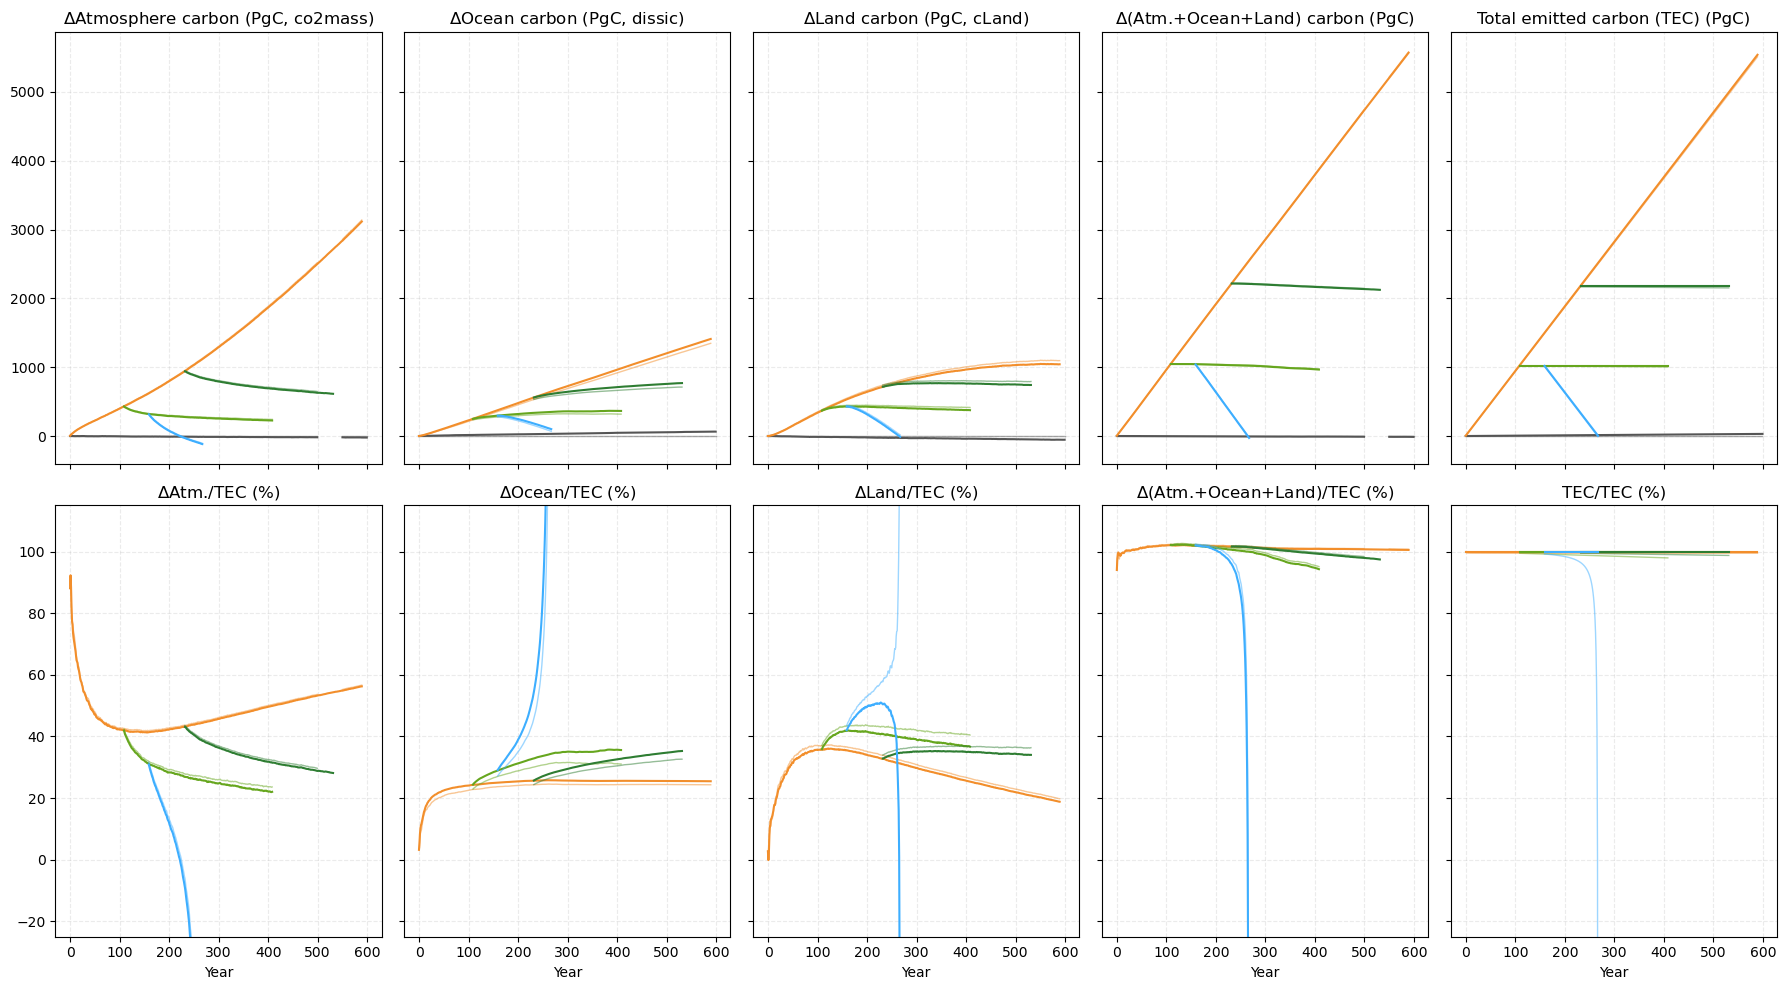

In [42]:
correct_for_piC = 'both'  # ['no', 'both']

for model in models:
    fig, ax = plt.subplots(2, 5, figsize=(18, 10),sharex=True,sharey='row')
    
    # --- reference (piControl) ---
    try:
        ref_cAtm = all_global_stats['co2mass'][model]['esm-piControl']
        ref_cOcean = all_global_stats[ocean_var][model]['esm-piControl']
        ref_cLand = all_global_stats[land_var][model]['esm-piControl']
        ref_cEm = all_global_stats['fco2antt'][model]['esm-piControl']
    except:
        print(f'No piControl for {model}')
        continue

    for run in runs:#[1:]:
        color = run_dict[run].color_id

        try:
            cAtm = all_global_stats['co2mass'][model][run]
            cOcean = all_global_stats[ocean_var][model][run]
            cLand = all_global_stats[land_var][model][run]
            cEm = all_global_stats['fco2antt'][model][run]
    
            
            cAtm, cOcean, cLand, cEm = xr.align(
                cAtm, cOcean, cLand, cEm,
                join="inner"
            )
    
            cAOL = cAtm + cOcean + cLand
    
            # --- align with reference ---
            cAtm_a, ref_cAtm_a = xr.align(cAtm, ref_cAtm, join="inner")
            cOcean_a, ref_cOcean_a = xr.align(cOcean, ref_cOcean, join="inner")
            cLand_a, ref_cLand_a = xr.align(cLand, ref_cLand, join="inner")
            cEm_a, ref_cEm_a = xr.align(cEm, ref_cEm, join="inner")
    
            # anomalies
            cAtm_anom = cAtm_a - ref_cAtm_a
            cOcean_anom = cOcean_a - ref_cOcean_a
            cLand_anom = cLand_a - ref_cLand_a
            cEm_anom = cEm_a - ref_cEm_a
            cAOL_anom = cAtm_anom + cOcean_anom + cLand_anom
    
            # --- cut where emissions are positive ---
            pos_mask = cEm_a > 0
            if pos_mask.any():
                t_cut = cEm_a.time.where(pos_mask, drop=True).max()
    
                cAtm = cAtm.sel(time=slice(None, t_cut))
                cOcean = cOcean.sel(time=slice(None, t_cut))
                cLand = cLand.sel(time=slice(None, t_cut))
                cAOL = cAOL.sel(time=slice(None, t_cut))
                cEm = cEm.sel(time=slice(None, t_cut))
    
                cAtm_anom = cAtm_anom.sel(time=slice(None, t_cut))
                cOcean_anom = cOcean_anom.sel(time=slice(None, t_cut))
                cLand_anom = cLand_anom.sel(time=slice(None, t_cut))
                cAOL_anom = cAOL_anom.sel(time=slice(None, t_cut))
                cEm_anom = cEm_anom.sel(time=slice(None, t_cut))
    
            # --- time axis ---
            time = cAtm.time
    
            # --- plotting ---
            if correct_for_piC in ['no', 'both']:
                ax[0,0].plot(time, cAtm, color=color)
                ax[0,1].plot(time, cOcean, color=color)
                ax[0,2].plot(time, cLand, color=color)
                ax[0,3].plot(time, cAOL, color=color)
                ax[0,4].plot(time, cEm, color=color)
    
            if correct_for_piC in ['yes', 'both']:
                ax[0,0].plot(time, cAtm_anom, color=color, alpha=0.5, linewidth=1)
                ax[0,1].plot(time, cOcean_anom, color=color, alpha=0.5, linewidth=1)
                ax[0,2].plot(time, cLand_anom, color=color, alpha=0.5, linewidth=1)
                ax[0,3].plot(time, cAOL_anom, color=color, alpha=0.5, linewidth=1)
                ax[0,4].plot(time, cEm_anom, color=color, alpha=0.5, linewidth=1)
    
            cEm_safe = cEm.where(cEm != 0)

            if run != 'esm-piControl':
                if correct_for_piC in ['no', 'both']:
                    ax[1,0].plot(time, cAtm / cEm_safe * 100, color=color)
                    ax[1,1].plot(time, cOcean / cEm_safe * 100, color=color)
                    ax[1,2].plot(time, cLand / cEm_safe * 100, color=color)
                    ax[1,3].plot(time, cAOL / cEm_safe * 100, color=color)
                    ax[1,4].plot(time, cEm / cEm_safe * 100, color=color)
        
                if correct_for_piC in ['yes', 'both']:
                    ax[1,0].plot(time, cAtm_anom / cEm_safe * 100, color=color, alpha=0.5, linewidth=1)
                    ax[1,1].plot(time, cOcean_anom / cEm_safe * 100, color=color, alpha=0.5, linewidth=1)
                    ax[1,2].plot(time, cLand_anom / cEm_safe * 100, color=color, alpha=0.5, linewidth=1)
                    ax[1,3].plot(time, cAOL_anom / cEm_safe * 100, color=color, alpha=0.5, linewidth=1)
                    ax[1,4].plot(time, cEm_anom / cEm_safe * 100, color=color, alpha=0.5, linewidth=1)

        except Exception as e:
            print(f'Nothing to plot for {model}, {run}: {e}')

    # --- styling ---
    for axi in ax.flatten():
        axi.grid(True, linestyle='--', alpha=0.25)

    xyears = [0, 100, 200, 300, 400, 500, 600]
    xticks = [cftime.DatetimeNoLeap(year, 1, 1) for year in xyears]
    for axi in ax[-1, :]:
        axi.set_ylim([-25, 115])
        axi.set_xlabel('Year')
        axi.set_xticks(xticks)
        axi.set_xticklabels(xyears)

    ax[0,0].set_title(r'$\Delta$Atmosphere carbon (PgC, co2mass)')
    ax[0,1].set_title(f'$\Delta$Ocean carbon (PgC, {ocean_var})')
    ax[0,2].set_title(f'$\Delta$Land carbon (PgC, {land_var})')
    ax[0,3].set_title(r'$\Delta$(Atm.+Ocean+Land) carbon (PgC)')
    ax[0,4].set_title(r'Total emitted carbon (TEC) (PgC)')

    ax[1,0].set_title(r'$\Delta$Atm./TEC (%)')
    ax[1,1].set_title(r'$\Delta$Ocean/TEC (%)')
    ax[1,2].set_title(r'$\Delta$Land/TEC (%)')
    ax[1,3].set_title(r'$\Delta$(Atm.+Ocean+Land)/TEC (%)')
    ax[1,4].set_title(r'TEC/TEC (%)')

    plt.tight_layout()